In [2]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mplhep as hep


In [3]:
file = uproot.open("C:/Users/HP/Documents/Practica Profesional/Analisis BosonHiggs/Data Sets/Run2012B_DoubleMuParked.root")
tree = file['Events']

# Listar ramas (variables físicas)

print(tree.keys())
tree.keys()
print (['nMuon', 'Muon_pt', 'Muon_eta', 'Muon_phi', 'Muon_mass', 'Muon_charge','Muon_pfRelIso04_all', 'Muon_dxy', 'Muon_dz', 'Muon_dxyErr', 'Muon_dzErr'])

# Archivos de simulación Monte Carlo 
# Señal: H → ZZ* → 4μ
file_higgs = uproot.open("C:/Users/HP/Documents/Practica Profesional/Analisis BosonHiggs/Data Sets/SMHiggsToZZTo4L.root")
tree_higgs = file_higgs['Events']

# Fondo: ZZ → 4μ
file_zz = uproot.open("C:/Users/HP/Documents/Practica Profesional/Analisis BosonHiggs/Data Sets/ZZTo4mu.root")
tree_zz = file_zz['Events']


['run', 'luminosityBlock', 'event', 'PV_npvs', 'PV_x', 'PV_y', 'PV_z', 'nMuon', 'Muon_pt', 'Muon_eta', 'Muon_phi', 'Muon_mass', 'Muon_charge', 'Muon_pfRelIso03_all', 'Muon_pfRelIso04_all', 'Muon_dxy', 'Muon_dxyErr', 'Muon_dz', 'Muon_dzErr', 'nElectron', 'Electron_pt', 'Electron_eta', 'Electron_phi', 'Electron_mass', 'Electron_charge', 'Electron_pfRelIso03_all', 'Electron_dxy', 'Electron_dxyErr', 'Electron_dz', 'Electron_dzErr', 'MET_pt', 'MET_phi']
['nMuon', 'Muon_pt', 'Muon_eta', 'Muon_phi', 'Muon_mass', 'Muon_charge', 'Muon_pfRelIso04_all', 'Muon_dxy', 'Muon_dz', 'Muon_dxyErr', 'Muon_dzErr']


In [5]:
# Extraer variables físicas de los tres archivos a dataframes 
# Datos reales (Run2012B)
df = tree.arrays(['Muon_pt', 'Muon_eta', 'Muon_phi', 'Muon_charge','Muon_pfRelIso04_all', 'Muon_dxy', 'Muon_dz', 'Muon_dxyErr', 'Muon_dzErr'], library="pd")

# Simulación Higgs MC

df_higgs_raw = tree_higgs.arrays(['Muon_pt', 'Muon_eta', 'Muon_phi', 'Muon_charge'],library="pd")

# Simulación fondo ZZ MC
df_zz_raw = tree_zz.arrays(['Muon_pt', 'Muon_eta', 'Muon_phi', 'Muon_charge'],library="pd")
                             
                                

In [6]:
# Separar columnas para simulaciones MC 
def preparar_mc(df_raw):
    df = df_raw[df_raw["Muon_pt"].apply(len) >= 4].copy()
    for i, idx in enumerate([0,1,2,3], start=1):
        df[f'pt{i}']     = df['Muon_pt'].apply(lambda x: x[idx])
        df[f'eta{i}']    = df['Muon_eta'].apply(lambda x: x[idx])
        df[f'phi{i}']    = df['Muon_phi'].apply(lambda x: x[idx])
        df[f'charge{i}'] = df['Muon_charge'].apply(lambda x: x[idx])
    # Filtro de carga neta cero (2 pares de muones de carga opuesta)
    df = df[(df["charge1"]+df["charge2"]+df["charge3"]+df["charge4"]) == 0].copy()
    return df

df_higgs = preparar_mc(df_higgs_raw)
df_zz    = preparar_mc(df_zz_raw)

print("Eventos Higgs MC:", len(df_higgs))
print("Eventos ZZ MC:   ", len(df_zz))

Eventos Higgs MC: 25972
Eventos ZZ MC:    378503


In [7]:
# Dividimos las listas en columnas individuales para 4 muones

df_4mu = df[df["Muon_pt"].apply(len) >= 4].copy() # nMuon mayor o igual a 4

# Muón 1

df_4mu['pt1'] = df_4mu['Muon_pt'].apply(lambda x: x[0])
df_4mu['eta1'] = df_4mu['Muon_eta'].apply(lambda x: x[0])
df_4mu['phi1'] = df_4mu['Muon_phi'].apply(lambda x: x[0])
df_4mu['charge1'] = df_4mu['Muon_charge'].apply(lambda x: x[0])
df_4mu['iso1'] = df_4mu['Muon_pfRelIso04_all'].apply(lambda x: x[0]) 
df_4mu['dxy1'] = df_4mu['Muon_dxy'].apply(lambda x: x[0])       
df_4mu['dz1'] = df_4mu['Muon_dz'].apply(lambda x: x[0])
df_4mu['dzErr1'] = df_4mu['Muon_dzErr'].apply(lambda x: x[0])
df_4mu['dxyErr1'] = df_4mu['Muon_dxyErr'].apply(lambda x: x[0])    

# Muón 2

df_4mu['pt2'] = df_4mu['Muon_pt'].apply(lambda x: x[1])
df_4mu['eta2'] = df_4mu['Muon_eta'].apply(lambda x: x[1])
df_4mu['phi2'] = df_4mu['Muon_phi'].apply(lambda x: x[1])
df_4mu['charge2'] = df_4mu['Muon_charge'].apply(lambda x: x[1])
df_4mu['iso2'] = df_4mu['Muon_pfRelIso04_all'].apply(lambda x: x[1])
df_4mu['dxy2'] = df_4mu['Muon_dxy'].apply(lambda x: x[1])
df_4mu['dz2'] = df_4mu['Muon_dz'].apply(lambda x: x[1])
df_4mu['dxyErr2'] = df_4mu['Muon_dxyErr'].apply(lambda x: x[1])
df_4mu['dzErr2'] = df_4mu['Muon_dzErr'].apply(lambda x: x[1])

# Muón 3 (¡Nuevo para el Higgs!)

df_4mu['pt3'] = df_4mu['Muon_pt'].apply(lambda x: x[2])
df_4mu['eta3'] = df_4mu['Muon_eta'].apply(lambda x: x[2])
df_4mu['phi3'] = df_4mu['Muon_phi'].apply(lambda x: x[2])
df_4mu['charge3'] = df_4mu['Muon_charge'].apply(lambda x: x[2])
df_4mu['iso3'] = df_4mu['Muon_pfRelIso04_all'].apply(lambda x: x[2])
df_4mu['dxy3'] = df_4mu['Muon_dxy'].apply(lambda x: x[2])
df_4mu['dz3'] = df_4mu['Muon_dz'].apply(lambda x: x[2])
df_4mu['dxyErr3'] = df_4mu['Muon_dxyErr'].apply(lambda x: x[2])
df_4mu['dzErr3'] = df_4mu['Muon_dzErr'].apply(lambda x: x[2])

# Muón 4 

df_4mu['pt4'] = df_4mu['Muon_pt'].apply(lambda x: x[3])
df_4mu['eta4'] = df_4mu['Muon_eta'].apply(lambda x: x[3])
df_4mu['phi4'] = df_4mu['Muon_phi'].apply(lambda x: x[3])
df_4mu['charge4'] = df_4mu['Muon_charge'].apply(lambda x: x[3])
df_4mu['iso4'] = df_4mu['Muon_pfRelIso04_all'].apply(lambda x: x[3])
df_4mu['dxy4'] = df_4mu['Muon_dxy'].apply(lambda x: x[3])
df_4mu['dz4'] = df_4mu['Muon_dz'].apply(lambda x: x[3])
df_4mu['dxyErr4'] = df_4mu['Muon_dxyErr'].apply(lambda x: x[3])
df_4mu['dzErr4'] = df_4mu['Muon_dzErr'].apply(lambda x: x[3])



In [8]:
# Mostrar las nuevas columnas ("pt1","pt2","pt3","pt4","eta1","eta2","eta3","eta4","phi1","phi2","phi3","phi4","charge1","charge2","charge3","charge4","iso1", "iso2", "iso3", "iso4","dxyErr1", "dzErr1")

print(df_4mu[["pt1","pt2","pt3","pt4","eta1","eta2","eta3","eta4","phi1","phi2","phi3","phi4","charge1","charge2","charge3","charge4","iso1","iso2","iso3","iso4","dxyErr1","dzErr1"]].head())

          pt1        pt2        pt3       pt4      eta1      eta2      eta3  \
4    7.375711   7.880538   8.608316  8.115600  1.241557  1.170679 -0.536403   
6   13.697009   9.624430  11.871896  9.884266 -0.114287 -0.261180  0.097859   
7   13.364430  48.732265   3.454617  3.519238  0.938585  0.928318  0.633687   
9   23.922316   7.937217   5.440603  5.945493 -1.239026  1.650931  1.641707   
16  22.147915   4.572840   6.188020  3.954496 -0.925457 -0.365892 -0.398481   

        eta4      phi1      phi2  ...  charge1  charge2  charge3  charge4  \
4   1.253896 -2.229106  3.054800  ...        1        1       -1        1   
6  -0.263532  2.346851  2.489782  ...        1       -1       -1        1   
7   0.652571 -2.174737 -2.173148  ...       -1        1       -1        1   
9   1.718757 -1.605496  0.954863  ...        1       -1       -1       -1   
16 -0.315460  2.162648 -0.767803  ...        1        1       -1        1   

        iso1       iso2        iso3   iso4   dxyErr1    dzErr1

In [9]:
# Valores únicos de las cargas (Para confirmar que hay muones + y -)

print("Valores únicos en charge1:", df_4mu["charge1"].unique())
print("Valores únicos en charge2:", df_4mu["charge2"].unique())
print("Valores únicos en charge3:", df_4mu["charge3"].unique())
print("Valores únicos en charge4:", df_4mu["charge4"].unique())

Valores únicos en charge1: [ 1 -1]
Valores únicos en charge2: [ 1 -1]
Valores únicos en charge3: [-1  1]
Valores únicos en charge4: [ 1 -1]


In [10]:
# Filtrar pares de muones con cargas opuestas 

df_pairs = df_4mu[(df_4mu["charge1"] + df_4mu["charge2"] + df_4mu["charge3"] + df_4mu["charge4"]) == 0].copy()


In [11]:
# Verificación de eventos totales con cuatro muones 

print("Eventos con cuatro muones:", len(df_4mu))
print("Eventos con cuatro muones y carga neta cero:", len(df_pairs))

Eventos con cuatro muones: 3340080
Eventos con cuatro muones y carga neta cero: 1235522


In [ ]:
# Tabla de flujo de cortes

# Calcular sip3d ← NUEVO: parámetro de impacto 3D significativo (skim.cxx)
for i in range(1, 5):
    ip3d = np.sqrt(df_pairs[f"dxy{i}"]**2 + df_pairs[f"dz{i}"]**2)
    sig  = np.sqrt(df_pairs[f"dxyErr{i}"]**2 + df_pairs[f"dzErr{i}"]**2)
    df_pairs[f"sip3d{i}"] = ip3d / sig

mask_pt  = (df_pairs["pt1"] > 5) & (df_pairs["pt2"] > 5) & (df_pairs["pt3"] > 5) & (df_pairs["pt4"] > 5)
mask_eta = (df_pairs["eta1"].abs() < 2.4) & (df_pairs["eta2"].abs() < 2.4) & (df_pairs["eta3"].abs() < 2.4) & (df_pairs["eta4"].abs() < 2.4)
mask_iso = (df_pairs["iso1"]<0.40) & (df_pairs["iso2"]<0.40) & (df_pairs["iso3"]<0.40) & (df_pairs["iso4"]<0.40)  
mask_sip = (df_pairs["sip3d1"]<4) & (df_pairs["sip3d2"]<4) & (df_pairs["sip3d3"]<4) & (df_pairs["sip3d4"]<4)      
mask_dxy = (df_pairs["dxy1"].abs()<0.5) & (df_pairs["dxy2"].abs()<0.5) & (df_pairs["dxy3"].abs()<0.5) & (df_pairs["dxy4"].abs()<0.5)  
mask_dz  = (df_pairs["dz1"].abs()<1.0)  & (df_pairs["dz2"].abs()<1.0)  & (df_pairs["dz3"].abs()<1.0)  & (df_pairs["dz4"].abs()<1.0)  

df_final = df_pairs[mask_pt & mask_eta & mask_iso & mask_sip & mask_dxy & mask_dz].copy()  

n_total = len(df_4mu)
n_pt    = len(df_pairs[mask_pt])
n_eta   = len(df_pairs[mask_pt & mask_eta])
n_iso   = len(df_pairs[mask_pt & mask_eta & mask_iso])    
n_sip   = len(df_pairs[mask_pt & mask_eta & mask_iso & mask_sip])  
n_final = len(df_pairs[mask_pt & mask_eta & mask_iso & mask_sip & mask_dxy & mask_dz])  

data_flujo = {
    'Corte aplicado': [
        'Sin filtros (4 muones)',
        'pT Líderes (>5, 5, 5, 5 GeV)',
        'Aceptancia Detector (|eta| < 2.4)',
        'Aislamiento iso < 0.40',          
        'Parámetro impacto sip3d < 4',     
        '|dxy| < 0.5 y |dz| < 1.0'        
    ],
    'Eventos Restantes': [n_total, n_pt, n_eta, n_iso, n_sip, n_final],  
    'Aceptancia (%)': [
        100.0,
        (n_pt    / n_total) * 100,
        (n_eta   / n_total) * 100,
        (n_iso   / n_total) * 100,   
        (n_sip   / n_total) * 100,   
        (n_final / n_total) * 100    
    ]
}
tabla_flujo = pd.DataFrame(data_flujo)
print("\nTabla de Flujo de Cortes (Análisis de Higgs 4l)")
print(tabla_flujo)





Tabla de Flujo de Cortes (Análisis de Higgs 4l)
                      Corte aplicado  Eventos Restantes  Aceptancia (%)
0             Sin filtros (4 muones)            3340080      100.000000
1       pT Líderes (>5, 5, 5, 5 GeV)             410620       12.293718
2  Aceptancia Detector (|eta| < 2.4)             398165       11.920822
3             Aislamiento iso < 0.40              28956        0.866925
4        Parámetro impacto sip3d < 4              20220        0.605375
5           |dxy| < 0.5 y |dz| < 1.0                295        0.008832


Datos reales filtrados: 295
Higgs MC filtrado:      20839
ZZ MC filtrado:         244778
Peso Higgs: 0.0003
Peso ZZ:    0.0008


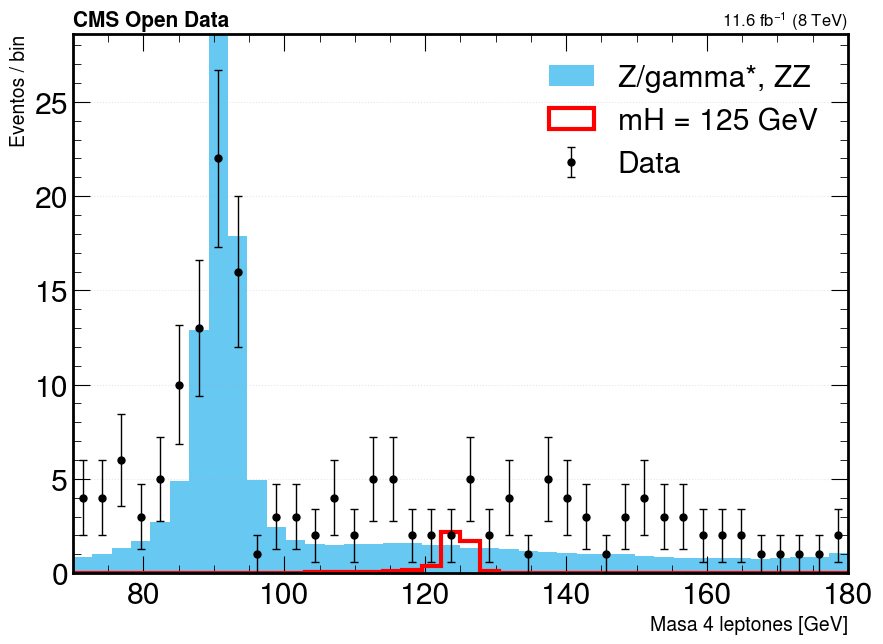

In [ ]:
# Estilo CMS 
hep.style.use("CMS")

# Párametros Físicos
m_mu = 0.10566  # Masa del muón [GeV/c²]

# Reconstrucción del 4-vector del sistema de 4 muones
def calcular_masa(df):
    px = 0; py = 0; pz = 0; E = 0
    for i in range(1, 5):
        pxi = df[f"pt{i}"] * np.cos(df[f"phi{i}"])
        pyi = df[f"pt{i}"] * np.sin(df[f"phi{i}"])
        pzi = df[f"pt{i}"] * np.sinh(df[f"eta{i}"])
        Ei  = np.sqrt(pxi**2 + pyi**2 + pzi**2 + m_mu**2)
        px += pxi; py += pyi; pz += pzi; E += Ei
    return np.sqrt(E**2 - (px**2 + py**2 + pz**2))

# Masa Invariante para los tres dataframes
df_pairs["M"] = calcular_masa(df_pairs)
df_higgs["M"] = calcular_masa(df_higgs)
df_zz["M"]    = calcular_masa(df_zz)

# Filtros datos reales — agregamos iso, sip3d, dxy, dz (skim.cxx)
mask_pt  = (df_pairs["pt1"]>5)  & (df_pairs["pt2"]>5)  & (df_pairs["pt3"]>5)  & (df_pairs["pt4"]>5)
mask_eta = (df_pairs["eta1"].abs()<2.4) & (df_pairs["eta2"].abs()<2.4) & (df_pairs["eta3"].abs()<2.4) & (df_pairs["eta4"].abs()<2.4)
mask_iso = (df_pairs["iso1"]<0.40) & (df_pairs["iso2"]<0.40) & (df_pairs["iso3"]<0.40) & (df_pairs["iso4"]<0.40) 
mask_sip = (df_pairs["sip3d1"]<4) & (df_pairs["sip3d2"]<4) & (df_pairs["sip3d3"]<4) & (df_pairs["sip3d4"]<4)      
mask_dxy = (df_pairs["dxy1"].abs()<0.5) & (df_pairs["dxy2"].abs()<0.5) & (df_pairs["dxy3"].abs()<0.5) & (df_pairs["dxy4"].abs()<0.5) 
mask_dz  = (df_pairs["dz1"].abs()<1.0)  & (df_pairs["dz2"].abs()<1.0)  & (df_pairs["dz3"].abs()<1.0)  & (df_pairs["dz4"].abs()<1.0)   

df_data_f = df_pairs[mask_pt & mask_eta & mask_iso & mask_sip & mask_dxy & mask_dz].copy() 

df_higgs_f = df_higgs[(df_higgs["pt1"]>5) & (df_higgs["pt2"]>5) &
                      (df_higgs["pt3"]>5) & (df_higgs["pt4"]>5) &
                      (df_higgs["eta1"].abs()<2.4) & (df_higgs["eta2"].abs()<2.4) &
                      (df_higgs["eta3"].abs()<2.4) & (df_higgs["eta4"].abs()<2.4)].copy()

df_zz_f = df_zz[(df_zz["pt1"]>5) & (df_zz["pt2"]>5) &
                (df_zz["pt3"]>5) & (df_zz["pt4"]>5) &
                (df_zz["eta1"].abs()<2.4) & (df_zz["eta2"].abs()<2.4) &
                (df_zz["eta3"].abs()<2.4) & (df_zz["eta4"].abs()<2.4)].copy()

print("Datos reales filtrados:", len(df_data_f))
print("Higgs MC filtrado:     ", len(df_higgs_f))
print("ZZ MC filtrado:        ", len(df_zz_f))

# Pesos oficiales del CERN reemplaza scale_higgs y scale_zz
lumi    = 11.58 * 1000
w_higgs = 0.0065 / 299973.0  * lumi
w_zz    = 0.077  / 1499064.0 * 1.386 * lumi

print(f"Peso Higgs: {w_higgs:.4f}")
print(f"Peso ZZ:    {w_zz:.4f}")

# Gráfico de la Distribución de la masa invariante
plt.figure(figsize=(10, 7))

# Fondo ZZ (azul)
plt.hist(df_zz_f["M"], bins=40, range=(70, 180), alpha=1.0,
         weights=np.full(len(df_zz_f), w_zz),      
         label="Z/gamma*, ZZ", color="#67C8F2", histtype='stepfilled')

# Señal Higgs (rojo)
plt.hist(df_higgs_f["M"], bins=40, range=(70, 180),
         weights=np.full(len(df_higgs_f), w_higgs),  
         label="mH = 125 GeV", color="red", histtype='step', linewidth=3)

# Datos reales (puntos negros)
counts, bin_edges = np.histogram(df_data_f["M"], bins=40, range=(70, 180))
bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
plt.errorbar(bin_centers, counts, yerr=np.sqrt(counts),
             fmt='o', color='black', markersize=5,
             capsize=3, elinewidth=1, linestyle='none', label='Data')

# Formato CMS
plt.title("CMS Open Data", loc='left', fontweight='bold', fontsize=15)
plt.title("11.6 fb$^{-1}$ (8 TeV)", loc='right', fontsize=12)
plt.xlabel("Masa 4 leptones [GeV]", fontsize=14)
plt.ylabel("Eventos / bin", fontsize=14)
plt.xlim(70, 180)
plt.ylim(0, counts.max() * 1.3)
plt.legend(loc='upper right', frameon=False)
plt.grid(axis='y', alpha=0.3)
plt.show()

Datos reales filtrados: 398165
Higgs MC filtrado:      20839
ZZ MC filtrado:         244778
Factor escala Higgs: 19.1067
Factor escala ZZ:    1.6266


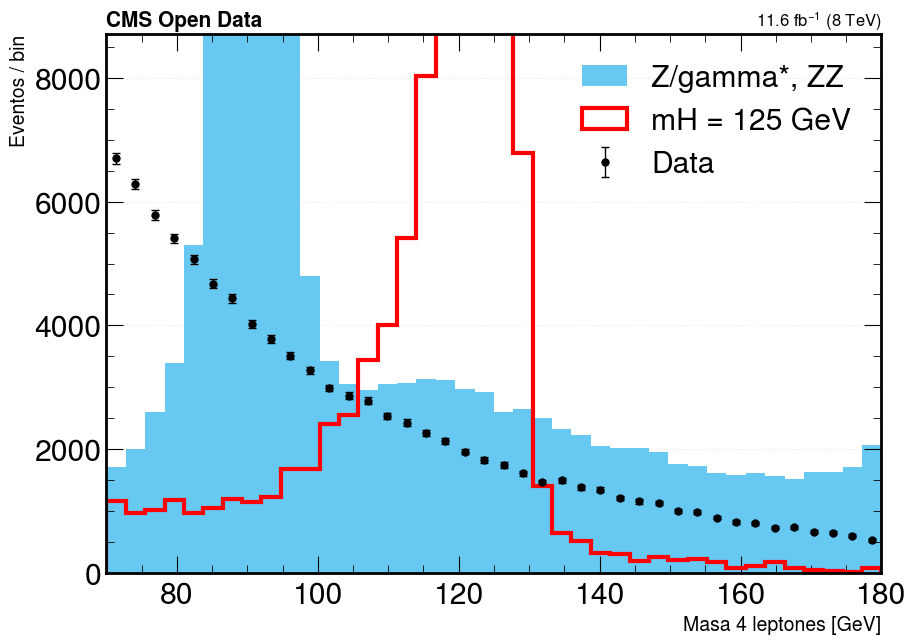

In [13]:
# Estilo CMS 
hep.style.use("CMS")

# Párametros Físicos
m_mu = 0.10566  # Masa del muón [GeV/c²]

# Reconstrucción del 4-vector del sistema de 4 muones
def calcular_masa(df):
    px = 0; py = 0; pz = 0; E = 0
    for i in range(1, 5):
        pxi = df[f"pt{i}"] * np.cos(df[f"phi{i}"])
        pyi = df[f"pt{i}"] * np.sin(df[f"phi{i}"])
        pzi = df[f"pt{i}"] * np.sinh(df[f"eta{i}"])
        Ei  = np.sqrt(pxi**2 + pyi**2 + pzi**2 + m_mu**2)
        px += pxi; py += pyi; pz += pzi; E += Ei
    return np.sqrt(E**2 - (px**2 + py**2 + pz**2))

# Masa Invariante para los tres dataframes
df_pairs["M"] = calcular_masa(df_pairs)
df_higgs["M"] = calcular_masa(df_higgs)
df_zz["M"]    = calcular_masa(df_zz)

# Filtros cinemáticos — datos reales
mask_pt  = (df_pairs["pt1"]>5) & (df_pairs["pt2"]>5) & \
           (df_pairs["pt3"]>5) & (df_pairs["pt4"]>5)
mask_eta = (df_pairs["eta1"].abs()<2.4) & (df_pairs["eta2"].abs()<2.4) & \
           (df_pairs["eta3"].abs()<2.4) & (df_pairs["eta4"].abs()<2.4)
df_data_f = df_pairs[mask_pt & mask_eta].copy()

df_higgs_f = df_higgs[(df_higgs["pt1"]>5) & (df_higgs["pt2"]>5) &
                      (df_higgs["pt3"]>5) & (df_higgs["pt4"]>5) &
                      (df_higgs["eta1"].abs()<2.4) & (df_higgs["eta2"].abs()<2.4) &
                      (df_higgs["eta3"].abs()<2.4) & (df_higgs["eta4"].abs()<2.4)].copy()

df_zz_f = df_zz[(df_zz["pt1"]>5) & (df_zz["pt2"]>5) &
                (df_zz["pt3"]>5) & (df_zz["pt4"]>5) &
                (df_zz["eta1"].abs()<2.4) & (df_zz["eta2"].abs()<2.4) &
                (df_zz["eta3"].abs()<2.4) & (df_zz["eta4"].abs()<2.4)].copy()

print("Datos reales filtrados:", len(df_data_f))
print("Higgs MC filtrado:     ", len(df_higgs_f))
print("ZZ MC filtrado:        ", len(df_zz_f))

# Factor de escala — normalizar MC al número de datos reales
scale_higgs = len(df_data_f) / len(df_higgs_f)
scale_zz    = len(df_data_f) / len(df_zz_f)

print(f"Factor escala Higgs: {scale_higgs:.4f}")
print(f"Factor escala ZZ:    {scale_zz:.4f}")

# Gráfico de la Distribución de la masa invariante
plt.figure(figsize=(10, 7))

# Fondo ZZ (azul) — escalado
plt.hist(df_zz_f["M"], bins=40, range=(70, 180), alpha=1.0,
         weights=np.full(len(df_zz_f), scale_zz),
         label="Z/gamma*, ZZ", color="#67C8F2", histtype='stepfilled')

# Señal Higgs (rojo) — escalado
plt.hist(df_higgs_f["M"], bins=40, range=(70, 180),
         weights=np.full(len(df_higgs_f), scale_higgs),
         label="mH = 125 GeV", color="red", histtype='step', linewidth=3)

# Datos reales (puntos negros)
counts, bin_edges = np.histogram(df_data_f["M"], bins=40, range=(70, 180))
bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
plt.errorbar(bin_centers, counts, yerr=np.sqrt(counts),
             fmt='o', color='black', markersize=5,
             capsize=3, elinewidth=1, linestyle='none', label='Data')

# Formato CMS
plt.title("CMS Open Data", loc='left', fontweight='bold', fontsize=15)
plt.title("11.6 fb$^{-1}$ (8 TeV)", loc='right', fontsize=12)
plt.xlabel("Masa 4 leptones [GeV]", fontsize=14)
plt.ylabel("Eventos / bin", fontsize=14)
plt.xlim(70, 180)
plt.ylim(0, counts.max() * 1.3)
plt.legend(loc='upper right', frameon=False)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
# Estilo CMS 
hep.style.use("CMS")

# Párametros Físicos
m_mu = 0.10566 # Masa del muón [GeV/c²]

# Reconstrucción del 4-vector del sistema de 4 muones 
# Se convierten las coordenadas cilíndricas (pt, eta, phi) a cartesianas
# y se suman los 4-vectores de cada muón: P_total = sum(P_i), i=1..4

def calcular_masa(df):
    px = 0; py = 0; pz = 0; E = 0
    for i in range(1, 5): 
        pxi = df[f"pt{i}"] * np.cos(df[f"phi{i}"])
        pyi = df[f"pt{i}"] * np.sin(df[f"phi{i}"])
        pzi = df[f"pt{i}"] * np.sinh(df[f"eta{i}"])
        Ei  = np.sqrt(pxi**2 + pyi**2 + pzi**2 + m_mu**2)
        px += pxi 
        py += pyi
        pz += pzi 
        E  += Ei
    return np.sqrt(E**2 - (px**2 + py**2 + pz**2))

# Masa Invariante de 4 muones 
df_pairs["M"]  = calcular_masa(df_pairs)
df_higgs["M"]  = calcular_masa(df_higgs)
df_zz["M"]     = calcular_masa(df_zz)

# Filtros (Cortes cinemáticos)
mask_pt  = (df_pairs["pt1"] > 5) & (df_pairs["pt2"] > 5) & \
           (df_pairs["pt3"] > 5) & (df_pairs["pt4"] > 5)
mask_eta = (df_pairs["eta1"].abs() < 2.4) & (df_pairs["eta2"].abs() < 2.4) & \
           (df_pairs["eta3"].abs() < 2.4) & (df_pairs["eta4"].abs() < 2.4)

df_data_f  = df_pairs[mask_pt & mask_eta].copy()
df_higgs_f = df_higgs[(df_higgs["pt1"]>5) & (df_higgs["pt2"]>5) &
                      (df_higgs["pt3"]>5) & (df_higgs["pt4"]>5) &
                      (df_higgs["eta1"].abs()<2.4) & (df_higgs["eta2"].abs()<2.4) &
                      (df_higgs["eta3"].abs()<2.4) & (df_higgs["eta4"].abs()<2.4)].copy()
df_zz_f    = df_zz[(df_zz["pt1"]>5) & (df_zz["pt2"]>5) &
                   (df_zz["pt3"]>5) & (df_zz["pt4"]>5) &
                   (df_zz["eta1"].abs()<2.4) & (df_zz["eta2"].abs()<2.4) &
                   (df_zz["eta3"].abs()<2.4) & (df_zz["eta4"].abs()<2.4)].copy()

# Gráfico de la Distribución de la masa invariante
plt.figure(figsize=(10, 7))

# EL FONDO (Azul) — simulación ZZ
plt.hist(df_zz_f["M"], bins=40, range=(70, 180), alpha=1.0,
         label="Z/gamma*, ZZ", color="#67C8F2", histtype='stepfilled')

# LA SEÑAL (Rojo) — simulación Higgs
plt.hist(df_higgs_f["M"], bins=40, range=(70, 180),
         label="mH = 125 GeV", color="red", histtype='step', linewidth=3)

# LOS DATOS (Puntos negros) — datos reales SIN filtrar primero
counts, bin_edges = np.histogram(df_data_f["M"], bins=40, range=(70, 180))
bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
plt.errorbar(bin_centers, counts, yerr=np.sqrt(counts),
             fmt='o', color='black', markersize=5,
             capsize=3, elinewidth=1,
             linestyle='none', label='Data')

# Ajustes de formato estilo CMS
plt.title("CMS Open Data", loc='left', fontweight='bold', fontsize=15)
plt.title("11.6 fb$^{-1}$ (8 TeV)", loc='right', fontsize=12)
plt.xlabel("Masa 4 leptones [GeV]", fontsize=14)
plt.ylabel("Eventos / bin", fontsize=14)
plt.xlim(70, 180)   # ← esto fija que empiece en 70
plt.ylim(0, counts.max() * 1.3)
plt.legend(loc='upper right', frameon=False)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
# Estilo CMS 
hep.style.use("CMS")

# Párametros Físicos
m_mu = 0.10566 # Masa del muón [GeV/c²]

# Reconstrucción del 4-vector del sistema de 4 muones 
# Se convierten las coordenadas cilíndricas (pt, eta, phi) a cartesianas
# y se suman los 4-vectores de cada muón: P_total = sum(P_i), i=1..4

def calcular_masa(df):
    px = 0; py = 0; pz = 0; E = 0
    for i in range(1, 5): 
        pxi = df[f"pt{i}"] * np.cos(df[f"phi{i}"])
        pyi = df[f"pt{i}"] * np.sin(df[f"phi{i}"])
        pzi = df[f"pt{i}"] * np.sinh(df[f"eta{i}"])
        Ei  = np.sqrt(pxi**2 + pyi**2 + pzi**2 + m_mu**2)
        px += pxi 
        py += pyi
        pz += pzi 
        E  += Ei
    return np.sqrt(E**2 - (px**2 + py**2 + pz**2))

# Masa Invariante de 4 muones 
df_pairs["M"] = calcular_masa(df_pairs)
df_higgs["M"] = calcular_masa(df_higgs)
df_zz["M"]    = calcular_masa(df_zz)

# Filtros (Cortes cinemáticos + aislamiento)
mask_pt  = (df_pairs["pt1"] > 5)  & (df_pairs["pt2"] > 5) & \
           (df_pairs["pt3"] > 5)  & (df_pairs["pt4"] > 5)
mask_eta = (df_pairs["eta1"].abs() < 2.4) & (df_pairs["eta2"].abs() < 2.4) & \
           (df_pairs["eta3"].abs() < 2.4) & (df_pairs["eta4"].abs() < 2.4)
mask_iso = (df_pairs["iso1"] < 0.35) & (df_pairs["iso2"] < 0.35) & \
           (df_pairs["iso3"] < 0.35) & (df_pairs["iso4"] < 0.35)

df_data_f  = df_pairs[mask_pt & mask_eta & mask_iso].copy()

df_higgs_f = df_higgs[(df_higgs["pt1"]>5) & (df_higgs["pt2"]>5) &
                      (df_higgs["pt3"]>5) & (df_higgs["pt4"]>5) &
                      (df_higgs["eta1"].abs()<2.4) & (df_higgs["eta2"].abs()<2.4) &
                      (df_higgs["eta3"].abs()<2.4) & (df_higgs["eta4"].abs()<2.4)].copy()

df_zz_f    = df_zz[(df_zz["pt1"]>5) & (df_zz["pt2"]>5) &
                   (df_zz["pt3"]>5) & (df_zz["pt4"]>5) &
                   (df_zz["eta1"].abs()<2.4) & (df_zz["eta2"].abs()<2.4) &
                   (df_zz["eta3"].abs()<2.4) & (df_zz["eta4"].abs()<2.4)].copy()

print("Datos reales filtrados: ", len(df_data_f))
print("Higgs MC filtrado:      ", len(df_higgs_f))
print("ZZ MC filtrado:         ", len(df_zz_f))

# Gráfico de la Distribución de la masa invariante
plt.figure(figsize=(10, 7))

# EL FONDO (Azul) — simulación ZZ
plt.hist(df_zz_f["M"], bins=40, range=(70, 180), alpha=1.0,
         label="Z/gamma*, ZZ", color="#67C8F2", histtype='stepfilled')

# LA SEÑAL (Rojo) — simulación Higgs
plt.hist(df_higgs_f["M"], bins=40, range=(70, 180),
         label="mH = 125 GeV", color="red", histtype='step', linewidth=3)

# LOS DATOS (Puntos negros) — datos reales
counts, bin_edges = np.histogram(df_data_f["M"], bins=40, range=(70, 180))
bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
plt.errorbar(bin_centers, counts, yerr=np.sqrt(counts), fmt='ko', markersize=5, label='Data')

# Ajustes de formato estilo CMS
plt.title("CMS Open Data", loc='left', fontweight='bold', fontsize=15)
plt.title("11.6 fb$^{-1}$ (8 TeV)", loc='right', fontsize=12)
plt.xlabel("Masa 4 leptones [GeV]", fontsize=14)
plt.ylabel("Eventos / bin", fontsize=14)
plt.xlim(70, 180)
plt.ylim(0, counts.max() * 1.3)
plt.legend(loc='upper right', frameon=False)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [15]:
# Ver cuántos muones tienen los eventos
df["n_muones"] = df["Muon_pt"].apply(len)
print(df["n_muones"].value_counts().head(10))

n_muones
2    12835141
3     5644975
1     3464980
4     2091945
0      799532
5      750080
6      281336
7      113992
8       50918
9       24148
Name: count, dtype: int64


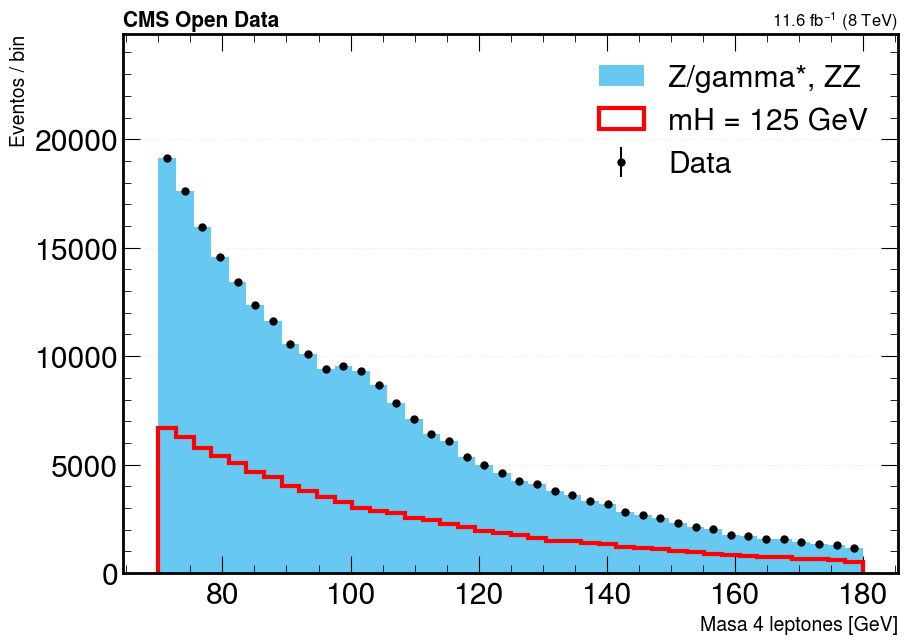

In [ ]:
# Grafica rara
# Estilo CMS 
hep.style.use("CMS")

# Párametros Físicos

m_mu = 0.10566 # Masa del muón [GeV/c²]

# Reconstrucción del 4-vector del sistema de 4 muones 
# Se convierten las coordenadas cilíndricas (pt, eta, phi) a cartesianas
# y se suman los 4-vectores de cada muón: P_total = sum(P_i), i=1..4

px = 0; py = 0; pz = 0; E = 0

for i in range(1, 5): 
    pxi = df_pairs[f"pt{i}"] * np.cos(df_pairs[f"phi{i}"])
    pyi = df_pairs[f"pt{i}"] * np.sin(df_pairs[f"phi{i}"])
    pzi = df_pairs[f"pt{i}"] * np.sinh(df_pairs[f"eta{i}"])
    Ei  = np.sqrt(pxi**2 + pyi**2 + pzi**2 + m_mu**2 )

    px += pxi 
    py += pyi
    pz += pzi 
    E += Ei
return np.sqrt(E**2 - (px**2 + py**2 + pz**2))




# Masa Invariante de 4 muones 

df_pairs["M"] = np.sqrt(E**2 - (px**2 + py**2 + pz**2))

# Filtros (Cortes cinemáticos)

mask_pt = (df_pairs["pt1"] > 5) & (df_pairs["pt2"] > 5) & (df_pairs["pt3"] > 5) & (df_pairs["pt4"] > 5)
mask_eta = (df_pairs["eta1"].abs() < 2.4) & (df_pairs["eta2"].abs() < 2.4) & (df_pairs["eta3"].abs() < 2.4) & (df_pairs["eta4"].abs() < 2.4)

df_filtrado = df_pairs[mask_pt & mask_eta].copy()

# Gráfico de la Distribución de la masa invariante

plt.figure(figsize=(10, 7))

# EL FONDO (El pico del Bosón Z): Usamos df_pairs para que se vea toda la masa (Azul)

plt.hist(df_pairs["M"], bins=40, range=(70, 180), alpha=1.0,
         label="Z/gamma*, ZZ", color="#67C8F2", histtype='stepfilled')

# LA SEÑAL (El Higgs): Usamos df_filtrado y ponemos el contorno rojo grueso
plt.hist(df_filtrado["M"], bins=40, range=(70, 180),
         label="mH = 125 GeV", color="red", histtype='step', linewidth=3)
# LOS DATOS (Los puntos negros)
counts, bin_edges = np.histogram(df_pairs["M"], bins=40, range=(70, 180))
bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
plt.errorbar(bin_centers, counts, yerr=np.sqrt(counts), fmt='ko', markersize=5, label='Data')

# Ajustes de formato estilo CMS
plt.title("CMS Open Data", loc='left', fontweight='bold', fontsize=15)
plt.title("11.6 fb$^{-1}$ (8 TeV)", loc='right', fontsize=12)
plt.xlabel("Masa 4 leptones [GeV]", fontsize=14)
plt.ylabel("Eventos / bin", fontsize=14)
plt.ylim(0, counts.max() * 1.3) 
plt.legend(loc='upper right', frameon=False)
plt.grid(axis='y', alpha=0.3)
plt.show()

